# Replication of Extended Data Figure 7I–J

**Manuscript:** Mantas et al. (2026) — *Anxa1+ dopamine neuron vulnerability defines prodromal Parkinson's disease bradykinesia and procedural motor learning impairment*

**Figure reference:** Extended Data Fig. 7 — *Characterization of Anxa1+ projections to the dorsal caudoputamen*

> Extended Data Fig. 7F–J: dLight fiber photometry recordings in dorsal caudoputamen (dCP)  
> combined with ChRmine-mediated optogenetic activation of Anxa1+ DANs at five laser intensities.

**Panels replicated here:**
- **Panel I** — Representative dLight trace during optogenetic stimulation (full session, 2 mW, dStr mouse)
- **Panel J** — Z-scored dLight peri-stimulus averages per mouse × intensity (dStr vs vStr)

**Panels not replicated (schematics/microscopy):**
- F: Mouse groups schematic + fluorescence images
- G: Experimental setup schematic + stimulation protocol
- H: Coronal section schematics showing recording locations

## Experimental design

Water-restricted Anxa1-Flp mice expressing ChRmine (for optogenetic activation of Anxa1+ DANs)
and dLight1.3b (dopamine sensor) in the caudoputamen freely nosepoked to trigger 1-second bilateral
SNc laser stimulation (40 Hz, 473 nm) with a 3-second inter-stimulation interval.
Two recording sites were compared:
- **dStr** (dorsal striatum / dCP): mice 776769, 776770
- **vStr** (ventral striatum / cCP): mice 802369, 802372

Five laser intensities were tested per animal: **0.1, 0.2, 0.5, 1, 2 mW**.

**Expected result:** Anxa1+ DAN activation evokes robust, intensity-dependent DA release in dCP
but markedly weaker responses in cCP, confirming preferential Anxa1+ innervation of dCP.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pynwb import NWBHDF5IO

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 9

NWB_DIR = Path("../../../nwb_output/opto_dlight")

# Mouse metadata
MOUSE_SITE = {
    "776769": "dStr",
    "776770": "dStr",
    "802369": "vStr",
    "802372": "vStr",
}
MICE_ORDER = ["776769", "776770", "802369", "802372"]
INTENSITIES = [0.1, 0.2, 0.5, 1.0, 2.0]  # mW

# Color map for intensities (low → high)
INTENSITY_COLORS = plt.cm.Blues(np.linspace(0.35, 0.95, len(INTENSITIES)))

print(f"NWB files found: {len(list(NWB_DIR.glob('sub-*.nwb')))}")

NWB files found: 20


## Load all sessions

In [2]:
def load_session(nwb_path):
    """Load key data from a single NWB file."""
    with NWBHDF5IO(nwb_path, mode="r") as io:
        nwb = io.read()

        subject_id = nwb.subject.subject_id
        session_id = nwb.session_id  # e.g. 'opto_dlight_dStr_2.0mW'
        # Parse intensity and site from session_id
        parts = session_id.split("_")
        site = parts[2]  # 'dStr' or 'vStr'
        intensity_mw = float(parts[3].replace("mW", ""))

        fp = nwb.acquisition["FiberPhotometryResponseSeries"]
        signal = fp.data[:].copy()
        timestamps = fp.timestamps[:].copy()

        stim_df = nwb.intervals["stimulation_episodes"].to_dataframe()
        stim_onsets = stim_df["start_time"].values.copy()
        stim_offsets = stim_df["stop_time"].values.copy()

    return dict(
        path=nwb_path,
        subject_id=subject_id,
        site=site,
        intensity_mw=intensity_mw,
        signal=signal,
        timestamps=timestamps,
        stim_onsets=stim_onsets,
        stim_offsets=stim_offsets,
    )


sessions = []
for nwb_path in sorted(NWB_DIR.glob("sub-*.nwb")):
    sess = load_session(nwb_path)
    sessions.append(sess)
    print(f"  {nwb_path.name:55s}  site={sess['site']}  {sess['intensity_mw']:.1f} mW  "
          f"n_stim={len(sess['stim_onsets'])}  fp_dur={sess['timestamps'][-1]:.0f}s")

  sub-776769_ses-oft_2024-03-01T10_16_32.nwb               site=dStr  2.0 mW  n_stim=163  fp_dur=1254s
  sub-776769_ses-oft_2024-03-05T15_09_16.nwb               site=dStr  1.0 mW  n_stim=152  fp_dur=1153s
  sub-776769_ses-oft_2024-03-06T12_48_19.nwb               site=dStr  0.2 mW  n_stim=165  fp_dur=1273s
  sub-776769_ses-oft_2024-03-06T13_54_29.nwb               site=dStr  0.5 mW  n_stim=175  fp_dur=1351s
  sub-776769_ses-oft_2024-03-06T14_58_22.nwb               site=dStr  0.1 mW  n_stim=161  fp_dur=1253s
  sub-776770_ses-oft_2024-03-01T10_41_41.nwb               site=dStr  2.0 mW  n_stim=169  fp_dur=1331s
  sub-776770_ses-oft_2024-03-05T15_32_17.nwb               site=dStr  1.0 mW  n_stim=156  fp_dur=1206s
  sub-776770_ses-oft_2024-03-06T13_13_03.nwb               site=dStr  0.2 mW  n_stim=168  fp_dur=1331s
  sub-776770_ses-oft_2024-03-06T14_20_46.nwb               site=dStr  0.5 mW  n_stim=163  fp_dur=1264s
  sub-776770_ses-oft_2024-03-06T15_22_14.nwb               site=dStr  0.1

## Panel I — Representative dLight trace during optogenetic stimulation

Full-session dLight signal for the 2 mW dStr session (mouse 776769), with optogenetic
stimulation episodes highlighted in blue. Nosepoke-triggered stimulation produces
transient increases in the dLight signal.

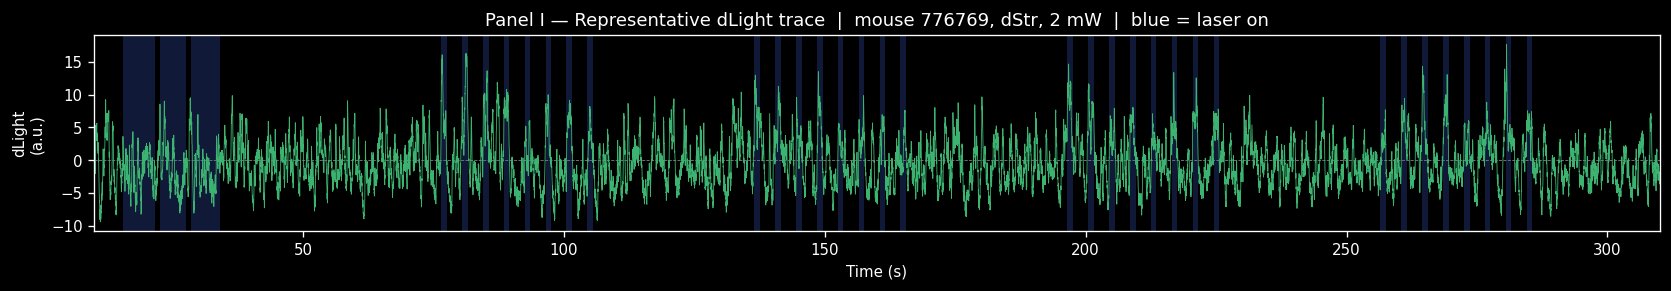

Saved → ../../../nwb_output/opto_dlight/extended_data_fig7I.pdf


In [3]:
# Pick the 2 mW dStr session for mouse 776769
rep = next(s for s in sessions if s["subject_id"] == "776769" and s["intensity_mw"] == 2.0)

sig = rep["signal"]
ts = rep["timestamps"]
onsets = rep["stim_onsets"]
offsets = rep["stim_offsets"]

# Show a 300-second window that captures many stim episodes
t_start, t_end = 10.0, 310.0
mask = (ts >= t_start) & (ts <= t_end)

fig, ax = plt.subplots(figsize=(14, 2.5))

ax.plot(ts[mask], sig[mask], linewidth=0.5, color="mediumseagreen", zorder=2)

# Shade stimulation episodes
for onset, offset in zip(onsets, offsets):
    if onset >= t_start and onset <= t_end:
        ax.axvspan(onset, min(offset + 0.1, t_end), color="royalblue", alpha=0.25, linewidth=0, zorder=1)

ax.set_xlim(t_start, t_end)
ax.set_xlabel("Time (s)")
ax.set_ylabel("dLight\n(a.u.)")
ax.set_title(
    f"Panel I — Representative dLight trace  |  mouse {rep['subject_id']}, {rep['site']}, "
    f"{rep['intensity_mw']:.0f} mW  |  blue = laser on"
)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--", zorder=0)

plt.tight_layout()
plt.savefig(NWB_DIR / "extended_data_fig7I.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {NWB_DIR / 'extended_data_fig7I.pdf'}")

## Panel J — Z-scored peri-stimulus dLight per mouse × intensity

For each stimulation episode, the dLight signal in a −2 to +5 s window around stim onset
is extracted and z-scored within that window (per-event normalization, as in the manuscript
methods). Epochs are averaged per session, then plotted per mouse with colors indicating
intensity (light → dark blue: 0.1, 0.2, 0.5, 1, 2 mW).

**Expected finding:** dStr mice (dCP) show robust, dose-dependent DA transients locked to
stim onset; vStr mice (cCP) show markedly weaker responses.

In [4]:
def compute_peri_stim_average(sess, pre_s=2.0, post_s=5.0, min_coverage=0.8):
    """Compute per-event z-scored peri-stim average.

    Z-scoring follows the manuscript approach: each epoch is z-scored within the
    full peri-event window (mean and std computed over the entire epoch),
    removing between-session baseline differences.
    """
    sig = sess["signal"]
    ts = sess["timestamps"]
    dt = np.median(np.diff(ts))
    fs = 1.0 / dt
    n_pre = int(pre_s * fs)
    n_post = int(post_s * fs)
    n_total = n_pre + n_post
    t_axis = np.linspace(-pre_s, post_s, n_total)

    epochs = []
    for onset in sess["stim_onsets"]:
        t0 = onset - pre_s
        t1 = onset + post_s
        idx = np.where((ts >= t0) & (ts < t1))[0]
        if len(idx) < n_total * min_coverage:
            continue
        # Interpolate to regular grid
        t_grid = np.linspace(t0, t1, n_total)
        epoch = np.interp(t_grid, ts[idx], sig[idx])
        # Per-event z-score within the full window
        mu, sd = epoch.mean(), epoch.std()
        if sd > 0:
            epoch = (epoch - mu) / sd
        epochs.append(epoch)

    if not epochs:
        return t_axis, None, None, 0

    arr = np.array(epochs)
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0) / np.sqrt(len(arr))
    return t_axis, mean, sem, len(arr)


# Pre-compute peri-stim averages for all sessions
PRE_S, POST_S = 2.0, 5.0
for sess in sessions:
    t_ax, mean, sem, n = compute_peri_stim_average(sess, pre_s=PRE_S, post_s=POST_S)
    sess["t_axis"] = t_ax
    sess["peri_mean"] = mean
    sess["peri_sem"] = sem
    sess["n_epochs"] = n
    print(f"  mouse {sess['subject_id']}  {sess['site']}  {sess['intensity_mw']:.1f} mW  → "
          f"{n} epochs extracted")

  mouse 776769  dStr  2.0 mW  → 163 epochs extracted
  mouse 776769  dStr  1.0 mW  → 145 epochs extracted
  mouse 776769  dStr  0.2 mW  → 164 epochs extracted
  mouse 776769  dStr  0.5 mW  → 174 epochs extracted
  mouse 776769  dStr  0.1 mW  → 160 epochs extracted
  mouse 776770  dStr  2.0 mW  → 169 epochs extracted
  mouse 776770  dStr  1.0 mW  → 153 epochs extracted
  mouse 776770  dStr  0.2 mW  → 168 epochs extracted
  mouse 776770  dStr  0.5 mW  → 161 epochs extracted
  mouse 776770  dStr  0.1 mW  → 161 epochs extracted
  mouse 802369  vStr  2.0 mW  → 144 epochs extracted
  mouse 802369  vStr  1.0 mW  → 160 epochs extracted
  mouse 802369  vStr  0.5 mW  → 163 epochs extracted
  mouse 802369  vStr  0.2 mW  → 169 epochs extracted
  mouse 802369  vStr  0.1 mW  → 160 epochs extracted
  mouse 802372  vStr  2.0 mW  → 160 epochs extracted
  mouse 802372  vStr  1.0 mW  → 160 epochs extracted
  mouse 802372  vStr  0.5 mW  → 160 epochs extracted
  mouse 802372  vStr  0.2 mW  → 172 epochs ext

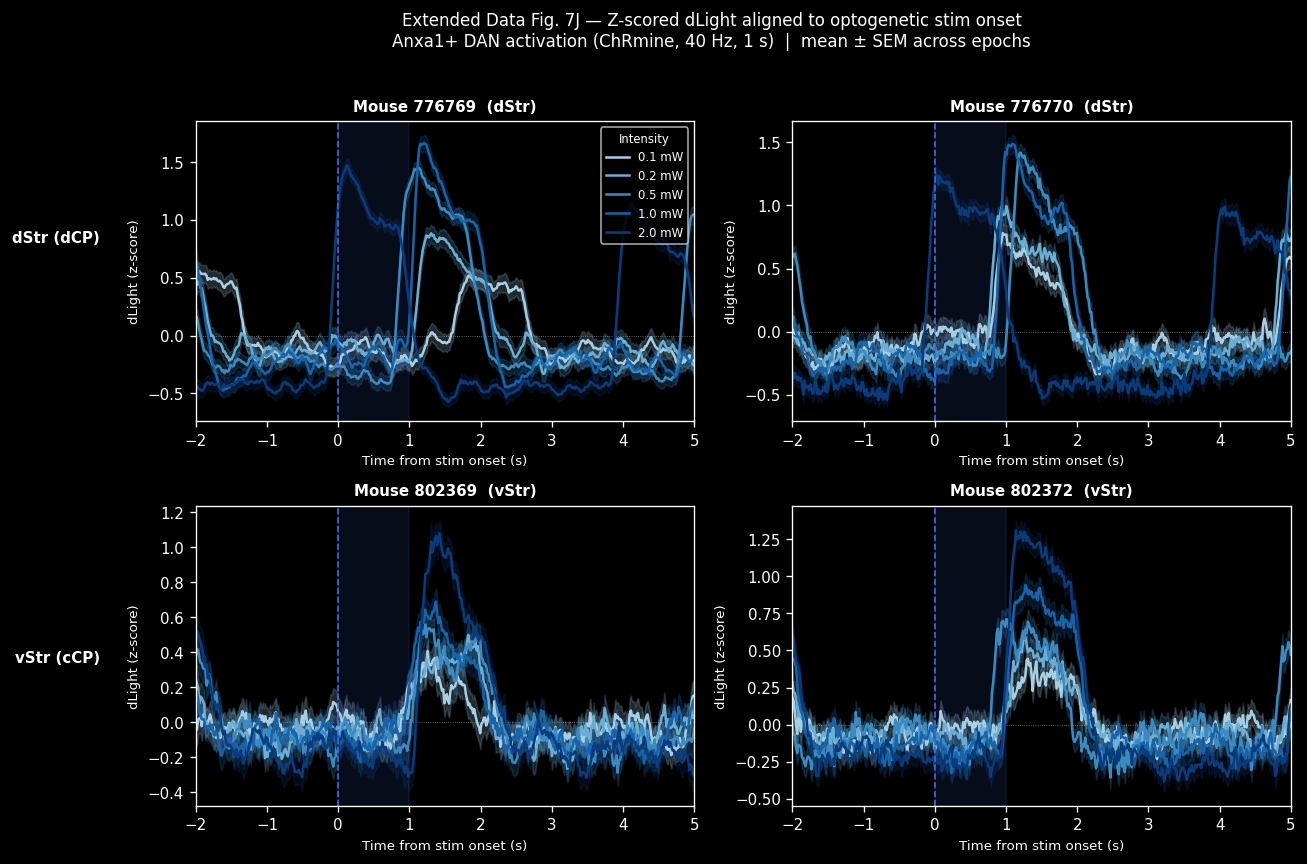

Saved → ../../../nwb_output/opto_dlight/extended_data_fig7J.pdf


In [5]:
# Panel J: 2×2 grid (one panel per mouse), lines colored by intensity
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
axes_flat = axes.flatten()

for ax_idx, mouse_id in enumerate(MICE_ORDER):
    ax = axes_flat[ax_idx]
    site = MOUSE_SITE[mouse_id]
    mouse_sessions = sorted(
        [s for s in sessions if s["subject_id"] == mouse_id],
        key=lambda s: s["intensity_mw"],
    )

    for sess, color in zip(mouse_sessions, INTENSITY_COLORS):
        if sess["peri_mean"] is None:
            continue
        label = f"{sess['intensity_mw']:.1f} mW"
        ax.plot(sess["t_axis"], sess["peri_mean"], color=color, linewidth=1.5, label=label)
        ax.fill_between(
            sess["t_axis"],
            sess["peri_mean"] - sess["peri_sem"],
            sess["peri_mean"] + sess["peri_sem"],
            color=color, alpha=0.2,
        )

    # Mark stimulation window
    ax.axvspan(0, 1.0, color="royalblue", alpha=0.12, label="1 s laser")
    ax.axvline(0, color="royalblue", linewidth=1.0, linestyle="--")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":", zorder=0)

    ax.set_title(f"Mouse {mouse_id}  ({site})", fontsize=9, fontweight="bold")
    ax.set_xlabel("Time from stim onset (s)", fontsize=8)
    ax.set_ylabel("dLight (z-score)", fontsize=8)
    ax.set_xlim(-PRE_S, POST_S)

    if ax_idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        intensity_handles = [(h, l) for h, l in zip(handles, labels) if "mW" in l]
        ax.legend(
            [h for h, _ in intensity_handles],
            [l for _, l in intensity_handles],
            fontsize=7, loc="upper right", title="Intensity", title_fontsize=7,
        )

# Add site labels to rows
for row, label in zip([0, 1], ["dStr (dCP)", "vStr (cCP)"]):
    fig.text(
        -0.01, 0.75 - row * 0.5, label,
        ha="right", va="center", fontsize=9, fontweight="bold",
        transform=fig.transFigure,
    )

fig.suptitle(
    "Extended Data Fig. 7J — Z-scored dLight aligned to optogenetic stim onset\n"
    "Anxa1+ DAN activation (ChRmine, 40 Hz, 1 s)  |  mean ± SEM across epochs",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.savefig(NWB_DIR / "extended_data_fig7J.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {NWB_DIR / 'extended_data_fig7J.pdf'}")

## Panel J (alternative) — Population overlay: dStr vs vStr per intensity

Alternative view showing dStr and vStr as overlaid mean traces per intensity level,
directly comparing the two recording sites. This highlights the dCP > cCP gradient
across the full intensity range.

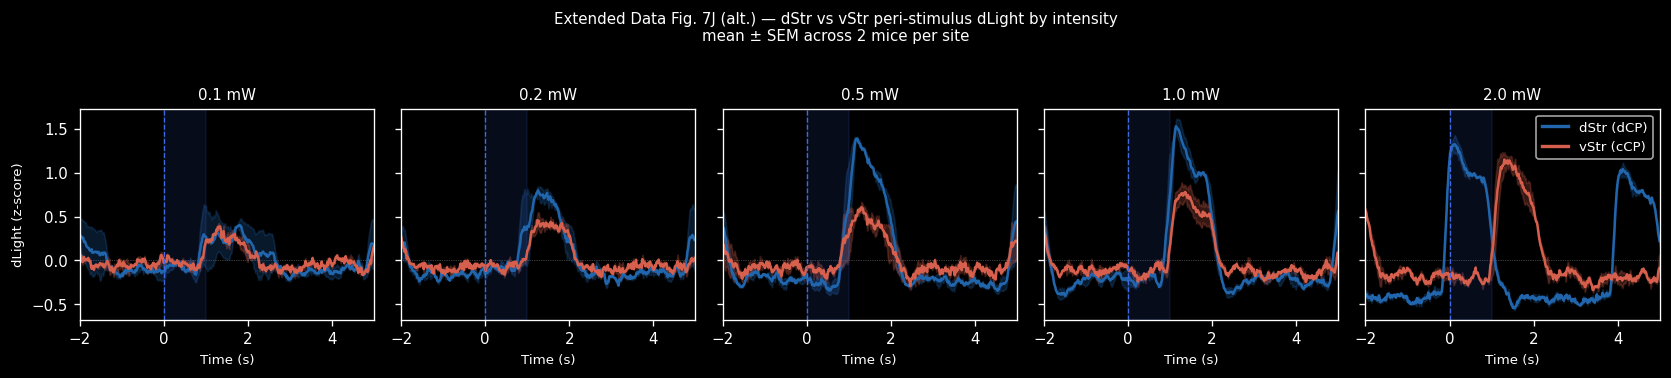

Saved → ../../../nwb_output/opto_dlight/extended_data_fig7J_alt.pdf


In [6]:
from collections import defaultdict

# Group sessions: site → intensity → list of mean traces
site_intensity_traces = defaultdict(lambda: defaultdict(list))
for sess in sessions:
    if sess["peri_mean"] is not None:
        site_intensity_traces[sess["site"]][sess["intensity_mw"]].append(sess["peri_mean"])

fig, axes = plt.subplots(1, len(INTENSITIES), figsize=(14, 3), sharey=True)

site_colors = {"dStr": "#2166ac", "vStr": "#d6604d"}  # blue = dCP, red = cCP

for ax, intensity in zip(axes, INTENSITIES):
    for site in ["dStr", "vStr"]:
        traces = site_intensity_traces[site].get(intensity, [])
        if not traces:
            continue
        arr = np.array(traces)
        grand_mean = arr.mean(axis=0)
        grand_sem = arr.std(axis=0) / np.sqrt(len(arr))
        t = sessions[0]["t_axis"]  # same t_axis for all sessions

        ax.plot(t, grand_mean, color=site_colors[site], linewidth=1.5, label=site)
        ax.fill_between(
            t,
            grand_mean - grand_sem,
            grand_mean + grand_sem,
            color=site_colors[site], alpha=0.25,
        )

    ax.axvspan(0, 1.0, color="royalblue", alpha=0.12)
    ax.axvline(0, color="royalblue", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="gray", linewidth=0.4, linestyle=":", zorder=0)
    ax.set_title(f"{intensity:.1f} mW", fontsize=9)
    ax.set_xlim(-PRE_S, POST_S)
    ax.set_xlabel("Time (s)", fontsize=8)

axes[0].set_ylabel("dLight (z-score)", fontsize=8)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=site_colors["dStr"], lw=2, label="dStr (dCP)"),
                   Line2D([0], [0], color=site_colors["vStr"], lw=2, label="vStr (cCP)")]
axes[-1].legend(handles=legend_elements, fontsize=8, loc="upper right")

fig.suptitle(
    "Extended Data Fig. 7J (alt.) — dStr vs vStr peri-stimulus dLight by intensity\n"
    "mean ± SEM across 2 mice per site",
    fontsize=9, y=1.03,
)
plt.tight_layout()
plt.savefig(NWB_DIR / "extended_data_fig7J_alt.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {NWB_DIR / 'extended_data_fig7J_alt.pdf'}")

## Peak response summary: dStr vs vStr across intensities

Peak z-scored dLight (max in 0–2 s post-onset window) per session, summarized by site and intensity.
This quantifies the dose-response relationship and the dCP > cCP difference.

In [7]:
import pandas as pd

records = []
for sess in sessions:
    if sess["peri_mean"] is None:
        continue
    t = sess["t_axis"]
    # Peak response in 0–2 s post-onset window
    post_mask = (t >= 0) & (t <= 2.0)
    peak = sess["peri_mean"][post_mask].max()
    records.append(dict(
        mouse_id=sess["subject_id"],
        site=sess["site"],
        intensity_mw=sess["intensity_mw"],
        peak_z=peak,
        n_epochs=sess["n_epochs"],
    ))

df = pd.DataFrame(records).sort_values(["site", "mouse_id", "intensity_mw"])
print(df.to_string(index=False))

# Summary table: mean peak z per site × intensity
summary = df.groupby(["site", "intensity_mw"])["peak_z"].agg(["mean", "std", "count"]).reset_index()
print("\n--- Mean peak z-score (0–2 s post-stim) by site × intensity ---")
print(summary.to_string(index=False))

mouse_id site  intensity_mw   peak_z  n_epochs
  776769 dStr           0.1 0.518180       160
  776769 dStr           0.2 0.883866       164
  776769 dStr           0.5 1.451115       174
  776769 dStr           1.0 1.663849       145
  776769 dStr           2.0 1.469782       163
  776770 dStr           0.1 0.780766       161
  776770 dStr           0.2 0.993761       168
  776770 dStr           0.5 1.417381       161
  776770 dStr           1.0 1.486906       153
  776770 dStr           2.0 1.244971       169
  802369 vStr           0.1 0.406764       160
  802369 vStr           0.2 0.498888       169
  802369 vStr           0.5 0.558590       163
  802369 vStr           1.0 0.689556       160
  802369 vStr           2.0 1.080467       144
  802372 vStr           0.1 0.444296       168
  802372 vStr           0.2 0.588940       172
  802372 vStr           0.5 0.711495       160
  802372 vStr           1.0 0.941601       160
  802372 vStr           2.0 1.309321       160

--- Mean pea

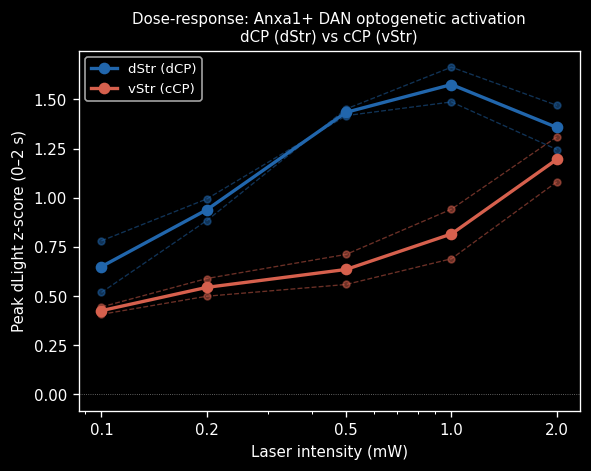

Saved → ../../../nwb_output/opto_dlight/extended_data_fig7_dose_response.pdf


In [8]:
# Dose-response plot: peak z vs intensity per site
fig, ax = plt.subplots(figsize=(5, 4))

for site, color in site_colors.items():
    site_df = df[df["site"] == site]
    # Individual mouse lines
    for mouse_id, grp in site_df.groupby("mouse_id"):
        grp_sorted = grp.sort_values("intensity_mw")
        ax.plot(grp_sorted["intensity_mw"], grp_sorted["peak_z"],
                "o--", color=color, alpha=0.5, linewidth=0.8, markersize=4)
    # Mean across mice
    mean_df = site_df.groupby("intensity_mw")["peak_z"].mean().reset_index()
    ax.plot(mean_df["intensity_mw"], mean_df["peak_z"],
            "o-", color=color, linewidth=2, markersize=6,
            label=f"{site} ({'dCP' if site == 'dStr' else 'cCP'})")

ax.set_xscale("log")
ax.set_xlabel("Laser intensity (mW)", fontsize=9)
ax.set_ylabel("Peak dLight z-score (0–2 s)", fontsize=9)
ax.set_title("Dose-response: Anxa1+ DAN optogenetic activation\ndCP (dStr) vs cCP (vStr)", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xticks(INTENSITIES)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(NWB_DIR / "extended_data_fig7_dose_response.pdf", bbox_inches="tight")
plt.show()
print(f"Saved → {NWB_DIR / 'extended_data_fig7_dose_response.pdf'}")